## Exploratory Data Analysis (EDA)

The goal of this analysis is to explore the UCI Phishing Websites dataset and understand the key characteristics that distinguish phishing websites from legitimate ones. 

This includes:
- Understanding the dataset structure and features  
- Checking for missing values and duplicates  
- Performing basic data cleaning to improve data quality  
- Analyzing the distribution of the target variable  
- Exploring feature distributions and relationships  
- Identifying important features for phishing detection  

The insights from this analysis will guide the model development phase.

In [1]:
from scipy.io import arff
import pandas as pd

# Load ARFF file
data = arff.loadarff("../data/raw-phishing.arff")

In [2]:
# Convert to DataFrame
df = pd.DataFrame(data[0])

In [3]:
# Convert bytes to normal strings
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

In [4]:
# Convert to integers
df = df.astype(int)
print(df.dtypes)

having_IP_Address              int64
URL_Length                     int64
Shortining_Service             int64
having_At_Symbol               int64
double_slash_redirecting       int64
Prefix_Suffix                  int64
having_Sub_Domain              int64
SSLfinal_State                 int64
Domain_registeration_length    int64
Favicon                        int64
port                           int64
HTTPS_token                    int64
Request_URL                    int64
URL_of_Anchor                  int64
Links_in_tags                  int64
SFH                            int64
Submitting_to_email            int64
Abnormal_URL                   int64
Redirect                       int64
on_mouseover                   int64
RightClick                     int64
popUpWidnow                    int64
Iframe                         int64
age_of_domain                  int64
DNSRecord                      int64
web_traffic                    int64
Page_Rank                      int64
G

In [5]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5206


In [6]:
# Remove duplicates 
df = df.drop_duplicates()

print(df.shape)

(5849, 31)


In [7]:
# Show first 5 rows
print(df.head())

   having_IP_Address  URL_Length  Shortining_Service  having_At_Symbol  \
0                 -1           1                   1                 1   
1                  1           1                   1                 1   
2                  1           0                   1                 1   
3                  1           0                   1                 1   
4                  1           0                  -1                 1   

   double_slash_redirecting  Prefix_Suffix  having_Sub_Domain  SSLfinal_State  \
0                        -1             -1                 -1              -1   
1                         1             -1                  0               1   
2                         1             -1                 -1              -1   
3                         1             -1                 -1              -1   
4                         1             -1                  1               1   

   Domain_registeration_length  Favicon  ...  popUpWidnow  Iframe  \

In [8]:
# Shape of the dataset
print("Shape:", df.shape)

Shape: (5849, 31)


In [9]:
# Information about the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 5849 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_IP_Address            5849 non-null   int64
 1   URL_Length                   5849 non-null   int64
 2   Shortining_Service           5849 non-null   int64
 3   having_At_Symbol             5849 non-null   int64
 4   double_slash_redirecting     5849 non-null   int64
 5   Prefix_Suffix                5849 non-null   int64
 6   having_Sub_Domain            5849 non-null   int64
 7   SSLfinal_State               5849 non-null   int64
 8   Domain_registeration_length  5849 non-null   int64
 9   Favicon                      5849 non-null   int64
 10  port                         5849 non-null   int64
 11  HTTPS_token                  5849 non-null   int64
 12  Request_URL                  5849 non-null   int64
 13  URL_of_Anchor                5849 non-null   int64
 

In [10]:
print(df.columns)

Index(['having_IP_Address', 'URL_Length', 'Shortining_Service',
       'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix',
       'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length',
       'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor',
       'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL',
       'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe',
       'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank',
       'Google_Index', 'Links_pointing_to_page', 'Statistical_report',
       'Result'],
      dtype='object')


In [11]:
# Check missing values
print(df.isnull().sum())

having_IP_Address              0
URL_Length                     0
Shortining_Service             0
having_At_Symbol               0
double_slash_redirecting       0
Prefix_Suffix                  0
having_Sub_Domain              0
SSLfinal_State                 0
Domain_registeration_length    0
Favicon                        0
port                           0
HTTPS_token                    0
Request_URL                    0
URL_of_Anchor                  0
Links_in_tags                  0
SFH                            0
Submitting_to_email            0
Abnormal_URL                   0
Redirect                       0
on_mouseover                   0
RightClick                     0
popUpWidnow                    0
Iframe                         0
age_of_domain                  0
DNSRecord                      0
web_traffic                    0
Page_Rank                      0
Google_Index                   0
Links_pointing_to_page         0
Statistical_report             0
Result    

In [12]:
# Target distribution
print(df['Result'].value_counts())

print()

# Percentage distribution
print(df['Result'].value_counts(normalize=True))

Result
-1    3019
 1    2830
Name: count, dtype: int64

Result
-1    0.516157
 1    0.483843
Name: proportion, dtype: float64


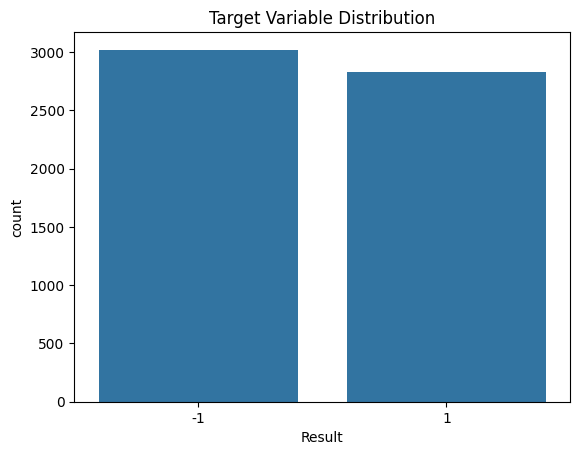

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Result', data=df)
plt.title("Target Variable Distribution")
plt.show()

In [14]:
# Summary statistics
print(df.describe())

       having_IP_Address   URL_Length  Shortining_Service  having_At_Symbol  \
count        5849.000000  5849.000000         5849.000000       5849.000000   
mean            0.132843    -0.616003            0.720294          0.588648   
std             0.991222     0.777323            0.693728          0.808459   
min            -1.000000    -1.000000           -1.000000         -1.000000   
25%            -1.000000    -1.000000            1.000000          1.000000   
50%             1.000000    -1.000000            1.000000          1.000000   
75%             1.000000    -1.000000            1.000000          1.000000   
max             1.000000     1.000000            1.000000          1.000000   

       double_slash_redirecting  Prefix_Suffix  having_Sub_Domain  \
count               5849.000000    5849.000000        5849.000000   
mean                   0.718242      -0.760301           0.065823   
std                    0.695852       0.649627           0.802448   
min         

In [ ]:
# Feature Value Distribution of 5 features
for col in df.columns[:5]:
    print(f"\nFeature: {col}")
    print(df[col].value_counts())


Feature: having_IP_Address
having_IP_Address
 1    3313
-1    2536
Name: count, dtype: int64

Feature: URL_Length
URL_Length
-1    4678
 1    1075
 0      96
Name: count, dtype: int64

Feature: Shortining_Service
Shortining_Service
 1    5031
-1     818
Name: count, dtype: int64

Feature: having_At_Symbol
having_At_Symbol
 1    4646
-1    1203
Name: count, dtype: int64

Feature: double_slash_redirecting
double_slash_redirecting
 1    5025
-1     824
Name: count, dtype: int64


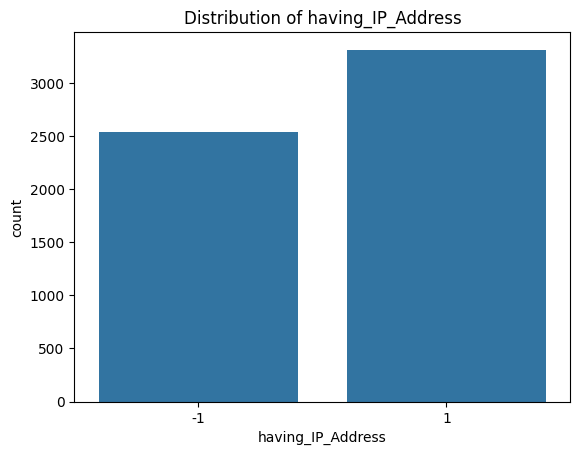

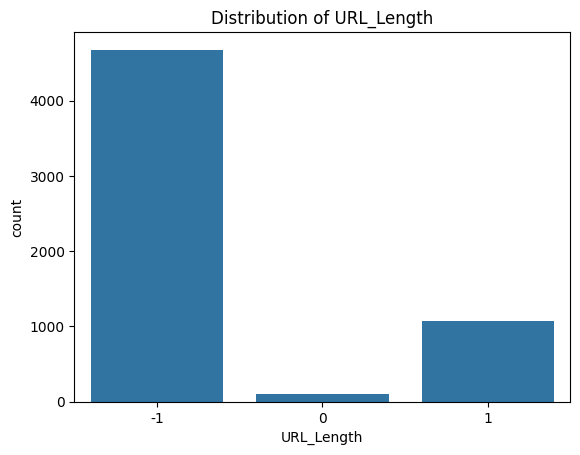

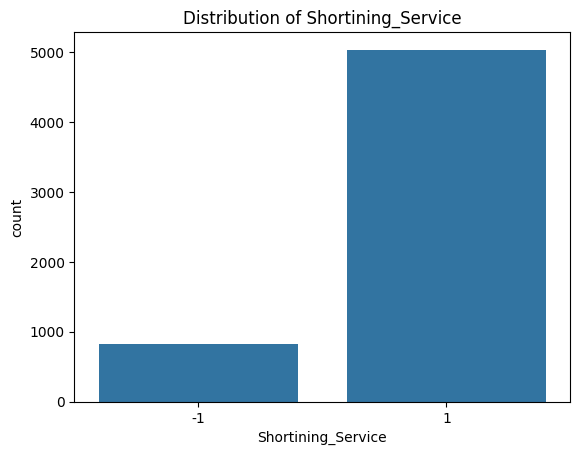

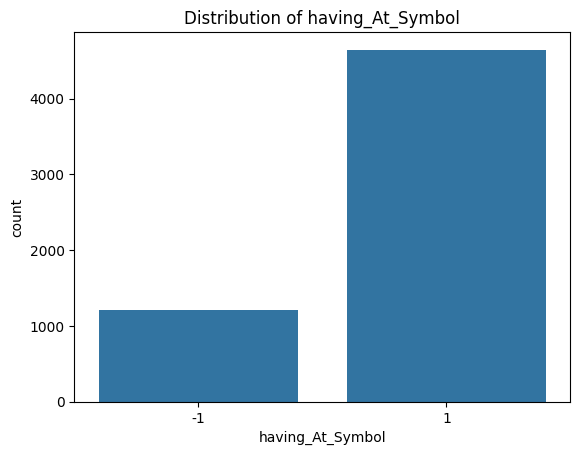

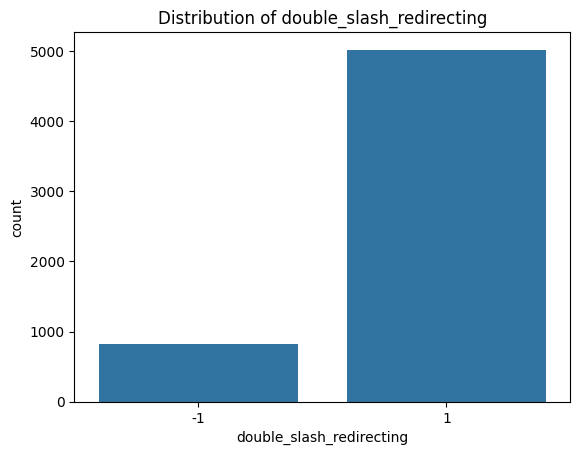

In [16]:
# Visualization of 5 features
features = df.columns[:5]

for col in features:
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

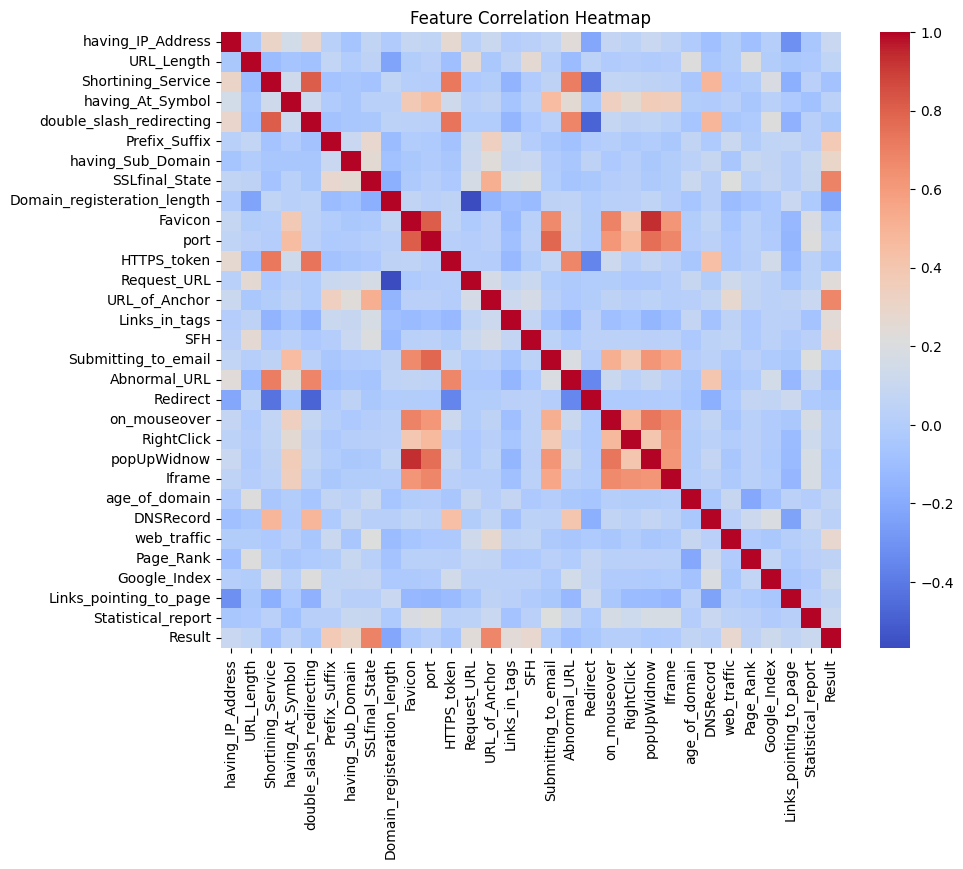

In [17]:
# Feature Correlation Heatmap
corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
# Check for multicollinearity by looking at the correlation matrix
import numpy as np

corr = df.corr()

# Get absolute correlations
corr_matrix = corr.abs()

# Remove self-correlation
np.fill_diagonal(corr_matrix.values, 0)

# Find highest correlation
max_corr = corr_matrix.max().max()

print("Maximum correlation between any two features:", max_corr)

Maximum correlation between any two features: 0.9331446650691144


In [28]:
# Identify pairs of features with high correlation (e.g., > 0.9)
import numpy as np

corr = df.corr().abs()
np.fill_diagonal(corr.values, 0)

high_corr = np.where(corr > 0.9)

for i, j in zip(*high_corr):
    print(corr.index[i], "-", corr.columns[j], ":", corr.iloc[i, j])

Favicon - popUpWidnow : 0.9331446650691144
popUpWidnow - Favicon : 0.9331446650691144


In [ ]:
# Feature Importance for EDA Insight
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import matplotlib.pyplot as plt

X_temp = df.drop("Result", axis=1)
y_temp = df["Result"]

model = DecisionTreeClassifier(random_state=42)
model.fit(X_temp, y_temp)

importances = model.feature_importances_

feat_importance = pd.Series(importances, index=X_temp.columns)
feat_importance = feat_importance.sort_values(ascending=False)

print(feat_importance.head(10))

SSLfinal_State                 0.591450
URL_of_Anchor                  0.122276
Prefix_Suffix                  0.037191
Links_in_tags                  0.031129
web_traffic                    0.028081
having_Sub_Domain              0.025127
Links_pointing_to_page         0.020230
Domain_registeration_length    0.015493
age_of_domain                  0.015396
SFH                            0.015271
dtype: float64


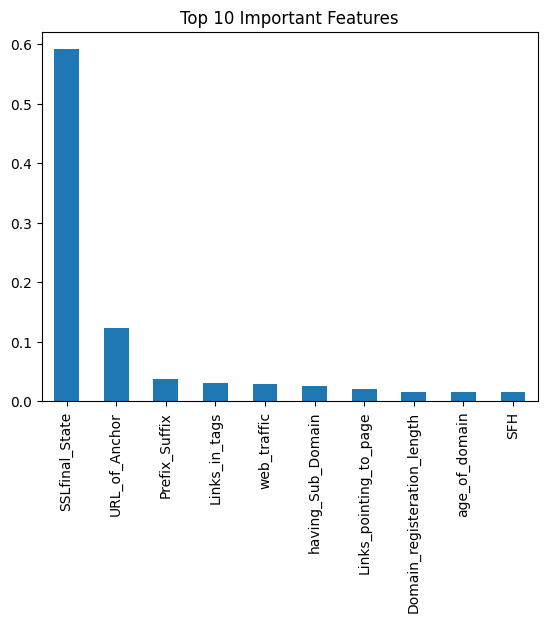

In [ ]:
# Plot Top 10 Important Features
feat_importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

### Feature Importance Summary (Based on Dataset Definitions)

Based on a preliminary feature importance analysis, the following features were identified as the most influential in distinguishing phishing websites from legitimate ones. These features align with the definitions provided in the dataset documentation.

- **SSLfinal_State**: This feature evaluates the legitimacy of the website’s SSL certificate, including whether HTTPS is used, the trustworthiness of the certificate issuer, and its age. Legitimate websites typically use trusted certificates with sufficient validity, while phishing sites often lack proper SSL configuration.   

- **URL_of_Anchor**: This feature measures the percentage of anchor (`<a>`) tags that link to external or suspicious domains, or do not link properly (e.g., empty or JavaScript links). A high percentage of such anchors is indicative of phishing behavior.

- **Prefix_Suffix**: This feature detects whether a dash (“-”) is used in the domain name. Phishing websites often add prefixes or suffixes separated by a dash to mimic legitimate domains and deceive users.

- **Links_in_tags**: This feature evaluates the percentage of links in HTML (`<meta>`, `<script>`, `<link>`) tags that point to external domains. Legitimate websites usually reference resources within the same domain, while phishing sites often rely on external links.

- **web_traffic**: This feature represents the popularity of a website based on traffic ranking. Legitimate websites typically have higher traffic and are ranked within known databases, while phishing websites often have little to no traffic due to their short lifespan.

- **having_Sub_Domain**: This feature measures the number of subdomains in the URL. Phishing websites often use multiple subdomains to create complex and misleading URLs, making them appear legitimate.

- **Links_pointing_to_page**: This feature counts the number of external links pointing to a webpage. Legitimate websites usually have multiple inbound links, while phishing websites often have very few or none due to their short existence.   

- **Domain_registeration_length**: This feature indicates how long a domain is registered. Phishing websites are typically registered for short durations, whereas legitimate domains are often registered for multiple years. 

- **age_of_domain**: This feature reflects how long the domain has existed. Phishing websites are usually newly created, while legitimate websites tend to have longer domain histories. 

- **SFH (Server Form Handler)**: This feature examines how form data is handled on a webpage. If forms submit data to external or suspicious domains, or contain empty handlers, it is a strong indicator of phishing activity. 

These features capture key structural, behavioral, and domain-based characteristics that are commonly associated with phishing attacks. Their high importance in the model highlights their effectiveness in distinguishing malicious websites from legitimate ones.

## EDA Summary

- The original dataset contains 11,055 instances with 30 features and one target variable. After removing duplicate rows, the dataset was reduced to 5,849 instances.  
- No missing values were found in the dataset.  
- All features are encoded using discrete values (-1, 0, 1).  
- The target variable is slightly imbalanced, with approximately 51.6% phishing websites and 48.4% legitimate websites.  
- A large number of duplicate rows were identified and removed to improve data quality and ensure reliable model evaluation.  
- Feature distribution analysis indicates that several attributes act as strong indicators of phishing behavior.  
- Correlation analysis revealed the presence of multicollinearity, with a maximum correlation of approximately 0.93 observed between features such as *Favicon* and *popUpWidnow*. These features likely capture similar webpage behavior patterns. However, no features were removed since tree-based models used in this project are not significantly affected by multicollinearity.  
- Preliminary feature importance analysis highlights key attributes influencing phishing detection.  
- No scaling or normalization is required due to the discrete nature of the features.  

The dataset has been cleaned and prepared, and is now ready for model training and evaluation.

In [ ]:
# Save cleaned dataset
df.to_csv("../data/processed-phishing.csv", index=False)

In [ ]:
# Prepare data for modeling
X = df.drop("Result", axis=1)
y = df["Result"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (5849, 30)
Target shape: (5849,)


In [22]:
# Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4679, 30)
Test shape: (1170, 30)
